# B4 — Risk-Stratified AIPW: Lower-Risk vs Elevated-Risk First Births

Runs the **exact validated AIPW setup from `07_aipw_primary_analysis.ipynb`**
independently within each of the two primary first-birth risk strata
(`lower_risk`, `elevated_risk`), rather than evaluating a single pooled
model on subgroups. Each stratum gets its own 5-fold respondent-grouped
cross-fitting, its own propensity/outcome nuisance models, and its own AIPW
estimate — this is a deliberate methodological choice (not fitting one
shared model and slicing predictions), since sample size and confounder-
outcome relationships may genuinely differ between strata, especially given
how much smaller `elevated_risk` is.

**Interpretation rule, identical to notebook 07: these are
selection-on-observables causal-style estimates, not randomized causality**,
credible only to the extent the confounder set below is sufficient.

**Not run here.** Written but not executed, per instruction — no commands
run, no model fit, no bootstrap performed while authoring this notebook.
Run it locally in VS Code.

**Population for this notebook:** first births only
(`risk_stratum_primary` in `{lower_risk, elevated_risk}`) **and**
`facility_type` in `{public, private}`. Multiparous records
(`not_applicable_multiparous`) and `other`-sector records are excluded
entirely, not just from a contrast.

**Confounder set — deliberately deviates from notebook 07 in one respect.**
`birth_order` is excluded here (unlike notebook 07's 8-variable set), since
every record in this notebook's population is a first birth
(`birth_order == 1` by construction of the risk strata) — it would be
constant and non-informative in either nuisance model. All other
confounders, and all other methodology, are unchanged from notebook 07.

**No sensitivity analyses are run in this notebook**, per instruction —
that is a later step.

## 1. Imports, paths, constants

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

pd.set_option("display.max_columns", None)

V2_PATH = Path("../../data/processed/df_model_v2.parquet")

OUTPUTS_DIR = Path("../../outputs")
TABLES_DIR = OUTPUTS_DIR / "tables"
FIGURES_DIR = OUTPUTS_DIR / "figures"
METADATA_DIR = OUTPUTS_DIR / "metadata"
for d in (TABLES_DIR, FIGURES_DIR, METADATA_DIR):
    d.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
N_FOLDS = 5
CLIP_EPS = 1e-6
TRIM_LOWER = 0.05
TRIM_UPPER = 0.95
N_BOOTSTRAP = 500
BOOTSTRAP_SEED = 42
OUTCOME_MODEL_TYPE = "xgboost"  # identical default to notebook 07

STRATA = ["lower_risk", "elevated_risk"]

## 2. Load `df_model_v2` (read-only) and restrict the population

First births only, in the two primary risk strata, public/private only.

In [2]:
df = pd.read_parquet(V2_PATH)  # read-only
n_loaded = len(df)

EXPECTED_ROW_COUNT = 201311
assert n_loaded == EXPECTED_ROW_COUNT, (
    f"df_model_v2 row count is {n_loaded}, expected {EXPECTED_ROW_COUNT}. Stop and investigate."
)

in_strata = df["risk_stratum_primary"].isin(STRATA)
in_facility = df["facility_type"].isin(["public", "private"])
analytic = df[in_strata & in_facility].copy().reset_index(drop=True)

# --- Assertion: only first births in the two primary strata, only public/private ---
assert set(analytic["risk_stratum_primary"].unique()) <= set(STRATA), \
    "Non-primary-stratum record leaked into the analytic sample."
assert set(analytic["facility_type"].unique()) <= {"public", "private"}, \
    "Non public/private facility type leaked into the analytic sample."
assert (analytic["birth_order"] == 1).all(), \
    "A non-first-birth record leaked into the risk-stratified analytic sample."

print(f"Excluded (multiparous or other-facility or non-primary-stratum): {n_loaded - len(analytic)}")
print(f"Analytic sample (first births, public/private, lower_risk + elevated_risk): {len(analytic)}")
print(analytic.groupby(["risk_stratum_primary", "facility_type"]).size())

analytic["exposure"] = (analytic["facility_type"] == "private").astype(int)
assert analytic["exposure"].isna().sum() == 0
assert analytic["csection"].isna().sum() == 0
print("No missing exposure or outcome values.")

Excluded (multiparous or other-facility or non-primary-stratum): 118885
Analytic sample (first births, public/private, lower_risk + elevated_risk): 82426
risk_stratum_primary  facility_type
elevated_risk         private           1237
                      public            1658
lower_risk            private          22750
                      public           56781
dtype: int64
No missing exposure or outcome values.


## 3. Confounder set — notebook 07's set minus `birth_order` (see note above), and the forbidden-variable guard

In [3]:
numeric_confounders = ["wealth_index", "education_years"]
categorical_confounders = ["residence", "religion", "social_group", "twin_order", "state"]
confounder_cols = numeric_confounders + categorical_confounders

forbidden_as_confounder = {
    "anc_visits", "anc_doctor", "anc_nurse_midwife", "anc_traditional_attendant",
    "anc_community_worker", "anc_anganwadi_worker", "anc_asha_worker", "anc_other_provider",
    "no_anc_provider", "first_anc_timing", "weight_measured_during_pregnancy",
    "bp_measured_during_pregnancy", "urine_sample_during_pregnancy", "blood_sample_during_pregnancy",
    "told_about_pregnancy_complications", "counselled_vaginal_bleeding", "counselled_convulsions",
    "counselled_prolonged_labour", "counselled_severe_abdominal_pain", "counselled_high_blood_pressure",
    "facility_type", "delivery_place_code",
    "bmi", "health_insurance", "maternal_age",
    "birth_order",  # constant (==1) in this first-births-only population -- excluded here, unlike notebook 07
    "convulsions_during_pregnancy", "swelling_during_pregnancy",
    "total_children_ever_born", "preceding_birth_interval", "age_at_first_birth",
    "district",
    "respondent_id", "birth_index", "cluster_number", "household_number", "respondent_line_number",
    "sample_weight", "sample_weight_normalized", "primary_sampling_unit",
    "sample_stratum_v022", "sample_stratum_v023",
    "csection",
    "risk_stratum_primary", "risk_stratum_refined_sensitivity", "first_birth",
}

overlap = forbidden_as_confounder.intersection(set(confounder_cols))
assert not overlap, f"Forbidden/mediator variable found in confounder set: {overlap}"
print(f"Confounder set: {len(confounder_cols)} variables (birth_order excluded -- constant in this population). "
      f"No mediator/forbidden overlap confirmed.")

Confounder set: 7 variables (birth_order excluded -- constant in this population). No mediator/forbidden overlap confirmed.


## 4. Nuisance model factories (identical specification to notebook 07)

In [4]:
def make_propensity_pipeline(numeric_cols, categorical_cols):
    preprocessor = ColumnTransformer([
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median", add_indicator=True)),
            ("scale", StandardScaler()),
        ]), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ])
    return Pipeline([("pre", preprocessor), ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])


def make_outcome_pipeline(numeric_cols, categorical_cols, model_type):
    outcome_numeric = numeric_cols + ["exposure"]
    if model_type == "xgboost":
        preprocessor = ColumnTransformer([
            ("num", SimpleImputer(strategy="median", add_indicator=True), outcome_numeric),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ])
        clf = XGBClassifier(
            objective="binary:logistic", eval_metric="logloss",
            random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist",
            n_estimators=200, max_depth=4, learning_rate=0.05,
        )
    elif model_type == "logistic_regression":
        preprocessor = ColumnTransformer([
            ("num", Pipeline([
                ("impute", SimpleImputer(strategy="median", add_indicator=True)),
                ("scale", StandardScaler()),
            ]), outcome_numeric),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ])
        clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    else:
        raise ValueError(f"Unrecognized model_type: {model_type}")
    return Pipeline([("pre", preprocessor), ("clf", clf)])

print(f"Outcome model type: {OUTCOME_MODEL_TYPE}")

Outcome model type: xgboost


## 5. Reusable cross-fitted AIPW routine — one call per stratum

Identical logic to notebook 07's cross-fitting loop, wrapped as a function
so both strata get exactly the same treatment. Returns the OOF nuisance
arrays plus the per-stratum assertions already checked internally.

In [5]:
def run_cross_fitted_aipw(stratum_df, stratum_label):
    W = stratum_df[confounder_cols].copy()
    for col in categorical_confounders:
        W[col] = W[col].astype("string").fillna("Missing").astype(str)

    exposure = stratum_df["exposure"].to_numpy()
    outcome = stratum_df["csection"].astype(int).to_numpy()
    survey_weight = stratum_df["sample_weight_normalized"].to_numpy()
    groups = stratum_df["respondent_id"].to_numpy()

    n_stratum = len(stratum_df)
    assert len(W) == n_stratum, f"[{stratum_label}] Row count changed while building the confounder matrix."

    splitter = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    fold_assignments = np.full(n_stratum, -1, dtype=int)
    fold_indices = list(splitter.split(W, exposure, groups))

    for fold_id, (train_idx, test_idx) in enumerate(fold_indices):
        train_resp = set(groups[train_idx])
        test_resp = set(groups[test_idx])
        leak = train_resp & test_resp
        assert not leak, f"[{stratum_label}] Fold {fold_id}: {len(leak)} respondents leaked across train/held-out."
        fold_assignments[test_idx] = fold_id

    assert (fold_assignments >= 0).all(), f"[{stratum_label}] Some rows never assigned to a held-out fold."
    covered = np.concatenate([test_idx for _, test_idx in fold_indices])
    assert len(covered) == n_stratum and len(set(covered.tolist())) == n_stratum, \
        f"[{stratum_label}] Row coverage across folds is not an exact one-to-one partition."

    W_with_exposure = W.copy()
    W_with_exposure["exposure"] = exposure

    e_hat = np.full(n_stratum, np.nan)
    mu1_hat = np.full(n_stratum, np.nan)
    mu0_hat = np.full(n_stratum, np.nan)

    for fold_id, (train_idx, test_idx) in enumerate(fold_indices):
        prop_pipeline = make_propensity_pipeline(numeric_confounders, categorical_confounders)
        prop_pipeline.fit(W.iloc[train_idx], exposure[train_idx], clf__sample_weight=survey_weight[train_idx])
        e_hat[test_idx] = prop_pipeline.predict_proba(W.iloc[test_idx])[:, 1]

        outcome_pipeline = make_outcome_pipeline(numeric_confounders, categorical_confounders, OUTCOME_MODEL_TYPE)
        outcome_pipeline.fit(
            W_with_exposure.iloc[train_idx], outcome[train_idx], clf__sample_weight=survey_weight[train_idx],
        )

        held_out_treated = W_with_exposure.iloc[test_idx].copy()
        held_out_treated["exposure"] = 1
        mu1_hat[test_idx] = outcome_pipeline.predict_proba(held_out_treated)[:, 1]

        held_out_control = W_with_exposure.iloc[test_idx].copy()
        held_out_control["exposure"] = 0
        mu0_hat[test_idx] = outcome_pipeline.predict_proba(held_out_control)[:, 1]

    e_hat_clipped = np.clip(e_hat, CLIP_EPS, 1 - CLIP_EPS)

    assert not np.isnan(e_hat_clipped).any(), f"[{stratum_label}] NaN found in e_hat."
    assert not np.isnan(mu1_hat).any(), f"[{stratum_label}] NaN found in mu1_hat."
    assert not np.isnan(mu0_hat).any(), f"[{stratum_label}] NaN found in mu0_hat."
    assert (e_hat_clipped > 0).all() and (e_hat_clipped < 1).all(), \
        f"[{stratum_label}] Clipped propensity not strictly within (0, 1)."

    print(f"[{stratum_label}] Cross-fitting complete. N={n_stratum}, folds={N_FOLDS}, "
          f"no fold leakage, every row covered exactly once, no NaN nuisance predictions.")

    return {
        "fold_assignments": fold_assignments,
        "exposure": exposure,
        "outcome": outcome,
        "survey_weight": survey_weight,
        "e_hat_raw": e_hat,
        "e_hat_clipped": e_hat_clipped,
        "mu1_hat": mu1_hat,
        "mu0_hat": mu0_hat,
    }

## 6. Run cross-fitted AIPW independently within each stratum

In [6]:
stratum_frames = {s: analytic[analytic["risk_stratum_primary"] == s].copy().reset_index(drop=True) for s in STRATA}
stratum_results = {s: run_cross_fitted_aipw(stratum_frames[s], s) for s in STRATA}

for s in STRATA:
    counts = stratum_frames[s]["facility_type"].value_counts()
    print(f"{s}: N={len(stratum_frames[s])} | public={counts.get('public', 0)} | private={counts.get('private', 0)}")

[lower_risk] Cross-fitting complete. N=79531, folds=5, no fold leakage, every row covered exactly once, no NaN nuisance predictions.
[elevated_risk] Cross-fitting complete. N=2895, folds=5, no fold leakage, every row covered exactly once, no NaN nuisance predictions.
lower_risk: N=79531 | public=56781 | private=22750
elevated_risk: N=2895 | public=1658 | private=1237


## 7. AIPW point estimates and positivity diagnostics per stratum

In [7]:
def aipw_psi(y, a, e, mu1, mu0):
    psi1 = mu1 + (a / e) * (y - mu1)
    psi0 = mu0 + ((1 - a) / (1 - e)) * (y - mu0)
    return psi1, psi0


def aipw_point_estimate(y, a, e, mu1, mu0, weights):
    psi1, psi0 = aipw_psi(y, a, e, mu1, mu0)
    r1 = np.average(psi1, weights=weights)
    r0 = np.average(psi0, weights=weights)
    return r1, r0, r1 - r0, r1 / r0


point_estimates = {}
positivity_rows = []
for s in STRATA:
    res = stratum_results[s]
    r1, r0, rd, rr = aipw_point_estimate(
        res["outcome"], res["exposure"], res["e_hat_clipped"], res["mu1_hat"], res["mu0_hat"], res["survey_weight"],
    )
    point_estimates[s] = {"r1": r1, "r0": r0, "rd": rd, "rr": rr}
    print(f"[{s}] Adjusted private risk: {r1*100:.2f}% | Adjusted public risk: {r0*100:.2f}% | "
          f"RD: {rd*100:.2f} pts | RR: {rr:.3f}")

    e = res["e_hat_clipped"]
    a = res["exposure"]
    extreme = (e < TRIM_LOWER) | (e > TRIM_UPPER)
    for label, mask in [("overall", np.ones(len(e), dtype=bool)), ("private", a == 1), ("public", a == 0)]:
        positivity_rows.append({
            "stratum": s, "group": label, "n": int(mask.sum()),
            "propensity_min": float(e[mask].min()), "propensity_max": float(e[mask].max()),
            "propensity_mean": float(e[mask].mean()),
            "n_extreme": int(extreme[mask].sum()), "pct_extreme": round(float(extreme[mask].mean()) * 100, 2),
        })

positivity_summary = pd.DataFrame(positivity_rows)
positivity_summary.to_csv(TABLES_DIR / "b4_risk_stratified_positivity_summary.csv", index=False)
positivity_summary

[lower_risk] Adjusted private risk: 49.39% | Adjusted public risk: 19.46% | RD: 29.92 pts | RR: 2.538
[elevated_risk] Adjusted private risk: 70.61% | Adjusted public risk: 42.38% | RD: 28.23 pts | RR: 1.666


,stratum,group,n,propensity_min,propensity_max,propensity_mean,n_extreme,pct_extreme
0,lower_risk,overall,79531,0.005907,0.906144,0.294934,4206,5.29
1,lower_risk,private,22750,0.007346,0.906144,0.431822,110,0.48
2,lower_risk,public,56781,0.005907,0.878918,0.240088,4096,7.21
3,elevated_risk,overall,2895,0.008845,0.965352,0.451795,73,2.52
4,elevated_risk,private,1237,0.044368,0.965352,0.594524,5,0.40
5,elevated_risk,public,1658,0.008845,0.925111,0.345307,68,4.10


## 8. Save stratum-level row-level nuisance predictions

In [8]:
row_level_frames = []
for s in STRATA:
    res = stratum_results[s]
    frame = pd.DataFrame({
        "risk_stratum_primary": s,
        "respondent_id": stratum_frames[s]["respondent_id"].to_numpy(),
        "facility_type": stratum_frames[s]["facility_type"].to_numpy(),
        "exposure": res["exposure"],
        "csection": res["outcome"],
        "sample_weight_normalized": res["survey_weight"],
        "cluster_number": stratum_frames[s]["cluster_number"].to_numpy(),
        "sample_stratum_v022": stratum_frames[s]["sample_stratum_v022"].to_numpy(),
        "fold": res["fold_assignments"],
        "e_hat_raw": res["e_hat_raw"],
        "e_hat_clipped": res["e_hat_clipped"],
        "mu1_hat": res["mu1_hat"],
        "mu0_hat": res["mu0_hat"],
    })
    row_level_frames.append(frame)

row_level_combined = pd.concat(row_level_frames, ignore_index=True)
row_level_combined.to_csv(TABLES_DIR / "b4_risk_stratified_row_level_nuisance.csv", index=False)
print(f"Saved combined stratum-level nuisance predictions: {row_level_combined.shape}")

Saved combined stratum-level nuisance predictions: (82426, 13)


## 9. Joint PSU-cluster bootstrap — per-stratum CIs and the RD difference

A single bootstrap resample is drawn each replicate from the **combined**
first-births analytic sample, resampling PSUs (`cluster_number`) with
replacement within `sample_stratum_v022` design strata (not to be confused
with the risk strata) — this correctly propagates any shared-cluster
correlation between `lower_risk` and `elevated_risk` records into the
difference's uncertainty, rather than bootstrapping the two strata
independently. Within each replicate, the resampled rows are split by
`risk_stratum_primary` to compute that replicate's stratum-specific RD/RR,
using each row's already-computed (fixed) nuisance predictions — same
plug-in-bootstrap caveat as notebook 07.

In [9]:
combined = row_level_combined.copy()
combined_psu = combined["cluster_number"].to_numpy()
combined_stratum_design = combined["sample_stratum_v022"].to_numpy()
combined_risk_stratum = combined["risk_stratum_primary"].to_numpy()
combined_outcome = combined["csection"].to_numpy()
combined_exposure = combined["exposure"].to_numpy()
combined_weight = combined["sample_weight_normalized"].to_numpy()
combined_e = combined["e_hat_clipped"].to_numpy()
combined_mu1 = combined["mu1_hat"].to_numpy()
combined_mu0 = combined["mu0_hat"].to_numpy()


def resample_indices_within_strata(psu_ids, stratum_ids, rng):
    row_positions = np.arange(len(psu_ids))
    out = []
    for s in np.unique(stratum_ids):
        stratum_mask = stratum_ids == s
        psus_in_stratum = np.unique(psu_ids[stratum_mask])
        n_psu = len(psus_in_stratum)
        drawn_psus = rng.choice(psus_in_stratum, size=n_psu, replace=True)
        for drawn_psu in drawn_psus:
            out.append(row_positions[stratum_mask & (psu_ids == drawn_psu)])
    return np.concatenate(out)


rng = np.random.RandomState(BOOTSTRAP_SEED)
rd_reps = {s: np.empty(N_BOOTSTRAP) for s in STRATA}
rr_reps = {s: np.empty(N_BOOTSTRAP) for s in STRATA}
rd_diff_reps = np.empty(N_BOOTSTRAP)

for b in range(N_BOOTSTRAP):
    idx = resample_indices_within_strata(combined_psu, combined_stratum_design, rng)
    replicate_rd = {}
    for s in STRATA:
        s_mask = combined_risk_stratum[idx] == s
        s_idx = idx[s_mask]
        _, _, rd_b, rr_b = aipw_point_estimate(
            combined_outcome[s_idx], combined_exposure[s_idx], combined_e[s_idx],
            combined_mu1[s_idx], combined_mu0[s_idx], combined_weight[s_idx],
        )
        rd_reps[s][b] = rd_b
        rr_reps[s][b] = rr_b
        replicate_rd[s] = rd_b
    rd_diff_reps[b] = replicate_rd["lower_risk"] - replicate_rd["elevated_risk"]

print("Bootstrap complete.")

Bootstrap complete.


## 10. Assemble the stratified AIPW summary and bootstrap CI tables

In [10]:
summary_rows = []
for s in STRATA:
    pe = point_estimates[s]
    rd_ci = (np.percentile(rd_reps[s], 2.5), np.percentile(rd_reps[s], 97.5))
    rr_ci = (np.percentile(rr_reps[s], 2.5), np.percentile(rr_reps[s], 97.5))
    counts = stratum_frames[s]["facility_type"].value_counts()
    summary_rows.append({
        "risk_stratum": s,
        "n": len(stratum_frames[s]),
        "n_public": int(counts.get("public", 0)),
        "n_private": int(counts.get("private", 0)),
        "adjusted_private_risk_pct": pe["r1"] * 100,
        "adjusted_public_risk_pct": pe["r0"] * 100,
        "risk_difference_pct": pe["rd"] * 100,
        "risk_difference_ci_low_pct": rd_ci[0] * 100,
        "risk_difference_ci_high_pct": rd_ci[1] * 100,
        "risk_ratio": pe["rr"],
        "risk_ratio_ci_low": rr_ci[0],
        "risk_ratio_ci_high": rr_ci[1],
    })

rd_diff_point = point_estimates["lower_risk"]["rd"] - point_estimates["elevated_risk"]["rd"]
rd_diff_ci = (np.percentile(rd_diff_reps, 2.5), np.percentile(rd_diff_reps, 97.5))
summary_rows.append({
    "risk_stratum": "lower_risk_minus_elevated_risk (RD difference)",
    "n": np.nan, "n_public": np.nan, "n_private": np.nan,
    "adjusted_private_risk_pct": np.nan, "adjusted_public_risk_pct": np.nan,
    "risk_difference_pct": rd_diff_point * 100,
    "risk_difference_ci_low_pct": rd_diff_ci[0] * 100,
    "risk_difference_ci_high_pct": rd_diff_ci[1] * 100,
    "risk_ratio": np.nan, "risk_ratio_ci_low": np.nan, "risk_ratio_ci_high": np.nan,
})

stratified_summary = pd.DataFrame(summary_rows)
stratified_summary.to_csv(TABLES_DIR / "b4_risk_stratified_aipw_summary.csv", index=False)

bootstrap_ci_table = pd.concat([
    pd.DataFrame({"replicate": np.arange(N_BOOTSTRAP), "stratum": s,
                  "risk_difference_pct": rd_reps[s] * 100, "risk_ratio": rr_reps[s]})
    for s in STRATA
] + [pd.DataFrame({"replicate": np.arange(N_BOOTSTRAP), "stratum": "difference_lower_minus_elevated",
                    "risk_difference_pct": rd_diff_reps * 100, "risk_ratio": np.nan})], ignore_index=True)
bootstrap_ci_table.to_csv(TABLES_DIR / "b4_risk_stratified_bootstrap_results.csv", index=False)

print("Saved: b4_risk_stratified_aipw_summary.csv, b4_risk_stratified_bootstrap_results.csv")
stratified_summary

Saved: b4_risk_stratified_aipw_summary.csv, b4_risk_stratified_bootstrap_results.csv


,risk_stratum,n,n_public,n_private,adjusted_private_risk_pct,adjusted_public_risk_pct,risk_difference_pct,risk_difference_ci_low_pct,risk_difference_ci_high_pct,risk_ratio,risk_ratio_ci_low,risk_ratio_ci_high
0,lower_risk,79531.0,56781.0,22750.0,49.385451,19.461935,29.923516,28.857777,30.963522,2.537541,2.452220,2.615615
1,elevated_risk,2895.0,1658.0,1237.0,70.607767,42.375509,28.232258,22.017372,35.792196,1.666240,1.465632,1.963221
2,lower_risk_minus_elevated_risk (RD difference),NaN,NaN,NaN,NaN,NaN,1.691257,-5.963618,7.739335,NaN,NaN,NaN


## 11. Forest plot — Risk Difference by stratum, with the difference-in-RD

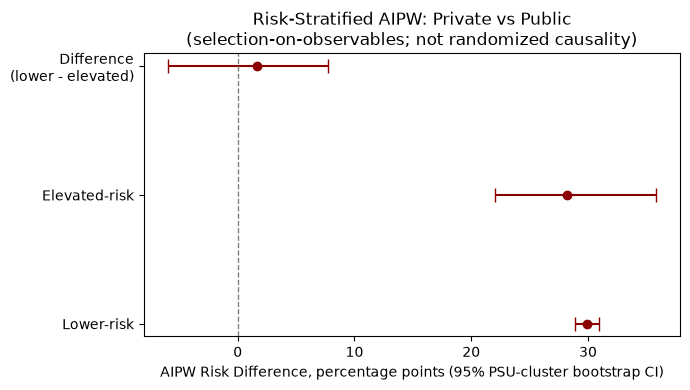

Saved: ..\..\outputs\figures\b4_risk_stratified_forest_plot.png


In [11]:
forest_labels = ["Lower-risk", "Elevated-risk", "Difference\n(lower - elevated)"]
means = [
    point_estimates["lower_risk"]["rd"] * 100,
    point_estimates["elevated_risk"]["rd"] * 100,
    rd_diff_point * 100,
]
ci_lows = [
    stratified_summary.loc[0, "risk_difference_ci_low_pct"],
    stratified_summary.loc[1, "risk_difference_ci_low_pct"],
    stratified_summary.loc[2, "risk_difference_ci_low_pct"],
]
ci_highs = [
    stratified_summary.loc[0, "risk_difference_ci_high_pct"],
    stratified_summary.loc[1, "risk_difference_ci_high_pct"],
    stratified_summary.loc[2, "risk_difference_ci_high_pct"],
]
err_low = [m - lo for m, lo in zip(means, ci_lows)]
err_high = [hi - m for m, hi in zip(means, ci_highs)]

fig, ax = plt.subplots(figsize=(7, 4))
y_pos = np.arange(len(forest_labels))
ax.errorbar(means, y_pos, xerr=[err_low, err_high], fmt="o", capsize=5, color="darkred")
ax.axvline(0, color="gray", linestyle="--", linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(forest_labels)
ax.set_xlabel("AIPW Risk Difference, percentage points (95% PSU-cluster bootstrap CI)")
ax.set_title("Risk-Stratified AIPW: Private vs Public\n(selection-on-observables; not randomized causality)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "b4_risk_stratified_forest_plot.png", dpi=200)
plt.show()
print("Saved:", FIGURES_DIR / "b4_risk_stratified_forest_plot.png")

## 12. Save metadata

In [12]:
metadata = {
    "random_state": RANDOM_STATE,
    "population": {
        "n_total_v2": n_loaded,
        "n_analytic_sample": len(analytic),
        "strata": {s: {
            "n": len(stratum_frames[s]),
            "n_public": int((stratum_frames[s]["facility_type"] == "public").sum()),
            "n_private": int((stratum_frames[s]["facility_type"] == "private").sum()),
        } for s in STRATA},
    },
    "exposure": {"private": 1, "public": 0},
    "confounder_set": confounder_cols,
    "note_on_birth_order": "Excluded from the confounder set in this notebook (unlike notebook 07's 8-variable set) because it is constant (==1) for every record in a first-births-only population and would be non-informative.",
    "cross_fitting": {
        "method": "StratifiedGroupKFold, stratified on exposure, grouped by respondent_id, run INDEPENDENTLY per stratum",
        "n_folds": N_FOLDS,
    },
    "nuisance_models": {
        "propensity": "LogisticRegression(max_iter=1000, random_state=42), survey-weighted via sample_weight_normalized",
        "outcome": f"{OUTCOME_MODEL_TYPE} S-learner (confounders + exposure as a feature), survey-weighted, fixed hyperparameters -- identical spec to notebook 07",
    },
    "clipping": {"method": "hard clip", "epsilon": CLIP_EPS},
    "bootstrap": {
        "method": "Joint PSU-cluster bootstrap over the COMBINED first-births sample, resampled with replacement within sample_stratum_v022 design strata; stratum-specific RD/RR and their difference computed from each replicate's resampled rows, split by risk_stratum_primary",
        "n_replicates": N_BOOTSTRAP,
        "seed": BOOTSTRAP_SEED,
        "ci_method": "percentile (2.5 / 97.5)",
        "caveat": "Nuisance predictions are fixed/plugged-in per replicate; nuisance models are not refit per replicate.",
    },
    "sensitivity_analyses_run": False,
    "interpretation_rule": (
        "Selection-on-observables causal-style estimates under consistency, positivity, and conditional "
        "exchangeability given the stated confounder set, estimated separately within each first-birth risk "
        "stratum. NOT randomized causality. Same excluded-confounder caveats as notebook 07 apply here."
    ),
}

with open(METADATA_DIR / "b4_risk_stratified_aipw_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, default=str)

print("Saved:", METADATA_DIR / "b4_risk_stratified_aipw_metadata.json")

Saved: ..\..\outputs\metadata\b4_risk_stratified_aipw_metadata.json
